# 1 基础
参考[Agent](../Agent/Agent.md)章节，了解Agent的基本概念和使用方法。  
参考[NLP](../NLP/NLP.md)章节，了解LLM的原理。

OpenAI 的消息系统

| Role | 说明 |
|------|------|
| `system` | 系统指令，设定助手行为 |
| `user` | 用户输入 |
| `assistant` | 模型回复 |
| `tool` | 工具调用结果返回 |

请求
```json
{
  "model": "gpt-4o",
  "messages": [
    {"role": "system","content": "你是一个有帮助的助手。"},
    {"role": "user","content": "今天天气怎么样？"}
  ]
}
```

响应
```json
{
  "id": "chatcmpl-abc123",
  "choices": [
    {
      "index": 0,
      "message": {"role": "assistant","content": "Hello! How can I help?"},
      "finish_reason": "stop"
    }
  ],
  "usage": {
    "prompt_tokens": 10,
    "completion_tokens": 15,
    "total_tokens": 25
  },
  "created": 1234567890,
  "model": "gpt-3.5-turbo"
}
```

定义工具 + 用户提问
```json
{
  "model": "gpt-4o",
  "messages": [
    {"role": "user","content": "北京今天的天气怎么样？"}
  ],
  "tools": [
    {
      "type": "function",
      "function": {
        "name": "get_weather",
        "description": "获取指定城市的天气信息",
        "parameters": {
          "type": "object",
          "properties": {
            "city": {
              "type": "string",
              "description": "城市名称"
            },
            "unit": {
              "type": "string",
              "enum": ["celsius", "fahrenheit"],
              "description": "温度单位"
            }
          },
          "required": ["city"]
        }
      }
    }
  ]
}
```

模型调用工具（响应）
```json
{
  "id": "chatcmpl-abc123",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": null,
        "tool_calls": [
          {
            "id": "call_abc123",
            "type": "function",
            "function": {
              "name": "get_weather",
              "arguments": "{\"city\": \"北京\", \"unit\": \"celsius\"}"
            }
          }
        ]
      },
      "finish_reason": "tool_calls"
    }
  ]
}
```

工具调用结果返回模型
```json
{
  "model": "gpt-4o",
  "messages": [
    {
      "role": "user",
      "content": "北京今天的天气怎么样？"
    },
    {
      "role": "assistant",
      "content": null,
      "tool_calls": [
        {
          "id": "call_abc123",
          "type": "function",
          "function": {
            "name": "get_weather",
            "arguments": "{\"city\": \"北京\", \"unit\": \"celsius\"}"
          }
        }
      ]
    },
    {
      "role": "tool",
      "tool_call_id": "call_abc123",
      "content": "{\"temperature\": 25, \"condition\": \"晴天\", \"humidity\": 45}"
    }
  ],
  "tools": [
    {
      ...
    }
  ]
}
```

模型最终回复
```json
{
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "北京今天天气晴朗，气温25°C，湿度45%。"
      },
      "finish_reason": "stop"
    }
  ]
}
```

## 1.1 对话

In [ ]:
# 快速调用
from openai import OpenAI
import os

client = OpenAI(
    api_key = os.getenv('DASHSCOPE_API_KEY'),
    base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1",
)

reponse = client.chat.completions.create(
    model = 'qwen3.6-flash-2026-04-16',
    messages = [
        {'role':'system','content':'You are a helpful assistant'},
        {'role':'user','content':'你好'}
    ]
)

print(reponse.choices[0].message.content)

你好！很高兴见到你！我是DeepSeek，一个乐于助人的AI助手。有什么我可以帮你的吗？无论是回答问题、提供建议，还是聊聊感兴趣的话题，我都很乐意陪你聊聊！😊


In [ ]:
# 封装基础聊天Agent 与 流式响应
import os
from openai import OpenAI
from typing import List,Dict

class Agent:
    def __init__(self,model='qwen3.6-flash-2026-04-16',api_key:str=None,base_url:str=None):
        '''

        '''
        self.model = model
        api_key = api_key or os.getenv('DASHSCOPE_API_KEY')
        base_url = base_url or "https://dashscope.aliyuncs.com/compatible-mode/v1"

        if not all([api_key,base_url]):
            raise ValueError("模型ID、API密钥和服务地址必须被提供或在.env文件中定义。")
        self.client = OpenAI(api_key=api_key,base_url=base_url)

    def chat(self,input:str=None):
        try: # 流式传输过程中遇到网络波动
            response = self.client.chat.completions.create(
                model = self.model,
                messages = [
                    {'role':'system','content':'You are a helpful assistant'},
                    {'role':'user','content':f'{input}'}
                ],
                stream = True # 流式响应
            )
            # 处理流式响应
            # 每个数据块chunk的 chunk.choices[0].delta.content 中提取当前生成的文本片段。
            # 对提取出的内容进行实时打印（实现打字机效果）或存入变量（获取完整回答）。
            full_response = ''
            for chunk in response:
                # if not chunk.choices:
                #     continue
                content = chunk.choices[0].delta.content or "" # 提取增量文本。 or "" 是为了防止 content 为 None。
                print(content, end="", flush=True) # 实时打印
                full_response += content
            print(f'\n{full_response}')# 存入变量，一次打印
        except Exception as e:
            print(f"调用LLM API时发生错误: {e}")
            return None

ChatAgent = Agent()
ChatAgent.chat('你是谁')

我是 Qwen（通义千问），由阿里巴巴集团旗下通义实验室自主研发的大语言模型。有什么我可以帮你的吗？
我是 Qwen（通义千问），由阿里巴巴集团旗下通义实验室自主研发的大语言模型。有什么我可以帮你的吗？


## 1.2 短期记忆

In [16]:
import os
from typing import List, Dict, Any
from openai import OpenAI

class MemoryAgent:
    def __init__(self,model:str='qwen3.5-plus-2026-04-20'):
        api_key = os.getenv('DASHSCOPE_API_KEY')
        if not api_key :
            raise ValueError('请设置 DASHSCOPE_API_KEY 环境变量')
        
        self.client = OpenAI(
            api_key=api_key,
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
        )
        self.model=model
        self.conversation_history:List[Dict[str,str]] = []

    def add_history(self,role:str,content:str):
        """添加消息到对话历史"""
        self.conversation_history.append(
            {'role':role,'content':content}
        )

        if len(self.conversation_history)>10: # 保留最后10个
            self.conversation_history = self.conversation_history[-10:]

    def ask(self,question:str)->str:
        self.add_history('user',question)

        messages = [
            {'role':'system','content':'你是一个有用的助手，能够好的回答用户的问题'},
        ]
        messages.extend(self.conversation_history)

        response = self.client.chat.completions.create(
            model=self.model,
            messages=messages,
            max_tokens=500,
        )
        answer = response.choices[0].message.content

        self.add_history('assistant',answer)

        return answer
    
    def clear_history(self):
        """清空对话历史"""
        self.conversation_history.clear()

In [17]:
def test_MemoryAgent():
    """测试基础问答 Agent"""
    print("=== 开始测试 ===")

    agent = MemoryAgent()

    questions = [
        '你好',
        '我最喜欢的动物是小狗',
        '你是谁',
        '我喜欢什么动物'
    ] # 能记住我们喜欢的动物

    for question in questions:
        answer = agent.ask(question)
        print(f"user:{question}")
        print(f"assistant:{answer}")

    print("\n测试完成")

if __name__ == "__main__":
    test_MemoryAgent()

=== 开始测试 ===
user:你好
assistant:你好！很高兴为你服务。请问有什么我可以帮你的吗？无论是回答问题、提供建议，还是协助处理具体任务，我都很乐意帮忙。
user:我最喜欢的动物是小狗
assistant:小狗确实特别讨人喜欢！它们忠诚、热情，而且总能敏锐地察觉到主人的情绪，给人带来满满的陪伴感和治愈力。🐾

你最喜欢哪种狗狗呢？比如温柔的大金毛、古灵精怪的柯基、自带“微笑脸”的柴犬，还是聪明机灵的中华田园犬？如果你已经有养狗，或者正打算养，也可以告诉我～我可以跟你分享一些狗狗护理的小贴士、训练技巧，或者推荐适合不同生活方式的犬种。聊聊你家（或你心中的）小狗吧！ 😊
user:你是谁
assistant:我是 Qwen（通义千问），由阿里巴巴集团旗下通义实验室自主研发的大语言模型。你可以把我当作一个随时在线的助手，无论是聊天、解答问题、提供建议，还是帮你处理文字、学习或工作相关的任务，我都很乐意为你效劳！

刚才聊到小狗，如果你有关于狗狗的疑问（比如品种选择、日常护理、训练技巧等），或者想换个话题，随时告诉我～ 😊
user:我喜欢什么动物
assistant:你刚才提到过，你最喜欢的动物是**小狗**呀！🐶 

是有什么关于狗狗的问题想问，还是想继续聊聊它们呢？随时告诉我哦～

测试完成


## 1.3 工具调用

### 1.3.1 Function Calling

In [ ]:
import os
import json
import requests
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# ---------------------- 心知天气工具类（调用真实的API查询天气） ----------------------
class SeniverseWeather:
    BASE_URL = "https://api.seniverse.com/v3"

    def __init__(self, api_key: str):
        self.api_key = api_key
        self.session = requests.Session()

    def _get(self, endpoint: str, **params) -> dict:
        params["key"] = self.api_key
        params.setdefault("language", "zh-Hans")
        params.setdefault("unit", "c")
        resp = self.session.get(f"{self.BASE_URL}/{endpoint}", params=params, timeout=10)
        resp.raise_for_status()
        results = resp.json().get("results", [])
        return results[0] if results else {}

    def now(self, location: str) -> dict:
        return self._get("weather/now.json", location=location)

    def daily(self, location: str, days: int = 3) -> dict:
        return self._get("weather/daily.json", location=location, days=days)

    def life(self, location: str) -> dict:
        return self._get("life/suggestion.json", location=location, days=1)

# ---------------------- 格式化函数 ----------------------
def format_now(data: dict) -> str:
    if "error" in data:
        return data["error"]
    loc = data.get("location", {}).get("name", "未知")
    now = data.get("now", {})
    return f"{loc}当前天气: {now.get('text', '?')} {now.get('temperature', '?')}°C"

def format_daily(data: dict) -> str:
    if "error" in data:
        return data["error"]
    loc = data.get("location", {}).get("name", "未知")
    lines = [f"{loc}天气预报:"]
    for d in data.get("daily", []):
        date = d.get("date", "?")
        lines.append(f"  {date}: {d.get('text_day', '?')} {d.get('high', '?')}°C / {d.get('text_night', '?')} {d.get('low', '?')}°C")
    return "\n".join(lines)

def format_life(data: dict) -> str:
    if "error" in data:
        return data["error"]
    loc = data.get("location", {}).get("name", "未知")
    labels = {"dressing": "穿衣", "uv": "紫外线", "car_washing": "洗车", "travel": "旅游", "flu": "感冒", "sport": "运动"}
    lines = [f"{loc}生活指数:"]
    for s in data.get("suggestion", []):
        for key, label in labels.items():
            if key in s:
                lines.append(f"  {label}: {s[key].get('brief', '?')}")
    return "\n".join(lines)

# ---------------------- Function Calling Agent ----------------------
class WeatherAgent:
    MODEL = "qwen-plus"

    def __init__(self):
        self.weather = SeniverseWeather(os.environ["SENIVERSE_API_KEY"])
        self.client = OpenAI(
            api_key=os.environ["DASHSCOPE_API_KEY"],
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        )
        self.conversation_history = []
        self.system_prompt = "你是友好的天气助手，可以调用工具查询天气。"

    def get_tools(self):
        return [
            {
                "type": "function",
                "function": {
                    "name": "get_weather_info",
                    "description": "查询天气，current=实时，forecast=预报，life=生活指数",
                    "parameters": {
                        "type": "object",
                        "properties": {
                            "location": {"type": "string"},
                            "wtype": {"type": "string", "enum": ["current", "forecast", "life"]}
                        },
                        "required": ["location", "wtype"]
                    }
                }
            }
        ]

    def get_weather_info(self, location: str, wtype: str):
        fetchers = {
            "current": (self.weather.now, format_now),
            "forecast": (self.weather.daily, format_daily),
            "life": (self.weather.life, format_life),
        }
        fetcher, formatter = fetchers.get(wtype)
        return formatter(fetcher(location))

    def chat(self, user_message: str):
        self.conversation_history.append({"role": "user", "content": user_message})
        messages = [{"role": "system", "content": self.system_prompt}]
        messages.extend(self.conversation_history)

        # 第一次调用
        response = self.client.chat.completions.create(
            model=self.MODEL, messages=messages, tools=self.get_tools(), tool_choice="auto"
        )

        msg = response.choices[0].message

        if msg.tool_calls:
            tool_call = msg.tool_calls[0]
            func_args = json.loads(tool_call.function.arguments)
            result = self.get_weather_info(func_args["location"], func_args["wtype"])

            messages.append(msg)
            messages.append({"role": "tool", "tool_call_id": tool_call.id, "content": result})

            # 第二次调用
            final = self.client.chat.completions.create(model=self.MODEL, messages=messages)
            answer = final.choices[0].message.content
        else:
            answer = msg.content

        self.conversation_history.append({"role": "assistant", "content": answer})
        return answer

In [19]:
# ==================== 测试 ====================
agent = WeatherAgent()
agent.chat("查询长沙未来三天的天气状况，哪一天适合外出运动")

'根据长沙未来三天的天气预报：\n\n- **5月8日（周四）**：阴，15°C～23°C，体感较凉润，云量多、无阳光，适合轻度户外活动，但光照不足可能影响运动兴致；  \n- **5月9日（周五）**：多云，15°C～24°C，气温适中，云量减少，紫外线温和，风力较小，是**最适宜外出运动的一天**；  \n- **5月10日（周六）**：多云，18°C～26°C，白天气温略高，午后体感稍暖，但仍在舒适范围内，也适合运动（建议避开中午高温时段，优选清晨或傍晚）。\n\n✅ **综合推荐：5月9日（周五）最适合外出运动**——温度宜人、云量适中、昼夜温差适中（9℃），且无降水风险，利于耐力型或户外锻炼（如慢跑、骑行、球类等）。\n\n需要我为你规划一个晨练/傍晚运动小贴士（比如穿衣建议、补水提醒）吗？ 😊'

### 1.3.2 联网搜索
千问自带搜索功能，传递 enable_search: true 参数可启用联网搜索功能。

更多请参考：https://help.aliyun.com/zh/model-studio/web-search#312c12c262fsr 包括强制联网，标注来源，时效性，搜索范围等等

In [12]:
api_key = os.getenv('DASHSCOPE_API_KEY')
# print(api_key)

client = OpenAI(
    api_key =  api_key,
    base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1",
)

reponse = client.chat.completions.create(
    model = 'qwen3.5-plus-2026-04-20',
    messages = [
        {'role':'user','content':'今天北京天气怎么样'}
    ],
    stream = False,
    extra_body={'enable_search':True}
)

print(reponse.choices[0].message.content)

根据您提供的知识库信息（数据主要集中于2026年5月上旬），北京今天（以近期5月7日-8日预报为参考）的天气概况如下：

🌤 **天气状况**：白天以晴为主，夜间晴间多云。
🌡 **气温区间**：最高气温约 **24℃～27℃**，最低气温约 **10℃～14℃**，早晚温差明显。
💨 **风力与预警**：偏北风3～4级，阵风6～7级，山区局地阵风可达8级以上。气象台已发布**大风蓝色预警**。风干物燥，外出请注意防风，谨防高空坠物，并注意用火用电安全。
👕 **生活提示**：
- 紫外线较强，建议涂抹防晒霜、佩戴墨镜或遮阳帽；
- 花粉浓度目前处于中低水平（主要为松科、杨柳科等），过敏人群建议佩戴口罩；
- 早晚体感偏凉，建议采用“洋葱式”穿衣，方便随时增减。

⚠️ **温馨提示**：知识库中的天气数据为特定时间点的预报快照。天气变化较快，如需获取您**确切查询日期**的实时天气，建议您直接打开“中国天气网”或搜索“气象北京”官方渠道查看最新实况与预警。如有具体出行日期或地点（如景区、郊区），告诉我可为您进一步匹配详细预报。


### 1.3.3网页抓取

### 1.3.4 代码解释器

### 1.3.5 知识库检索

### 1.3.6 MCP

# 2 推理与规划

## 2.1 ReAct 框架
ReAct = Reason（推理） + Act（行动）

参考[点击跳转到1.3.1 Function-Calling](#131-Function-Calling)

Reason 大模型推理(要不要调用工具、调用哪个、参数是什么) -> Act 行动(程序执行工具查询天气) -> 再次 Reason(把工具结果丢给大模型，整理成最终回答)

其中调用了两次LLM，
- 第一次：把用户问题 + 工具列表给模型，输出 tool_calls
- 第二次：把工具返回的天气结果塞回对话 → 模型基于真实数据，整理成自然语言回答

这是最简单的单轮 ReAct ，只会最多调用一次工具，走完两轮 LLM 就结束，适合查天气、查汇率等

完整 ReAct 是多轮while循环
- 思考要不要调用工具
- 调用工具
- 拿到结果
- 再思考还需不需要调用其他工具，再循环
- 直到模型判断「不用工具了，可以直接回答」才退出循环
- 加上最大循环次数，防止死循环

ReAct 模式的优势在于它的灵活性，能够根据每一步的执行结果动态调整后续行动。但这也意味着执行路径可能不稳定，适合需要探索的任务。

In [ ]:
import os
import json
import datetime
from openai import OpenAI

class ReActAgent:
    def __init__(self,model:str="qwen-plus",max_loops:int= 5):  # 设置多轮循环最大循环次数，防止死循环
        self.client = OpenAI(
            api_key=os.getenv("DASHSCOPE_API_KEY"),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        )
        self.model=model
        self.max_loops=max_loops
        self.conversation_history = [] # 对话记忆
        self.system_prompt = "你是一个能调用工具的智能助手。根据用户的问题判断是否需要调用工具来回答，需要工具就调用，不需要就直接回答。"

    # 工具定义
    def get_tools(self):
        return [
            {
                "type": "function",
                "function": {
                    "name": "get_local_time",
                    "description": "获取当前本机时间：小时、分钟、秒",
                    "parameters": {"type": "object", "properties": {}}
                }
            },
            {
                "type": "function",
                "function": {
                    "name": "calculator",
                    "description": "数学计算器",
                    "parameters": {
                        "type": "object",
                        "properties": {
                            "expr": {"type": "string", "description": "数学表达式，例如 10 + 20"}
                        },
                        "required": ["expr"]
                    }
                }
            }
        ]

    # 工具实现
    def get_local_time(self):
        now = datetime.datetime.now()
        return f"当前时间：小时={now.hour}, 分钟={now.minute}, 秒={now.second}"

    def calculator(self, expr):
        try:
            return str(eval(expr, {"__builtins__": None}, {}))
        except:
            return "计算失败"

    # 工具调用分发
    def execute_tool(self, func_name, args):
        if func_name == "get_local_time":
            return self.get_local_time()
        elif func_name == "calculator":
            return self.calculator(args.get("expr"))
        return "未知工具"

    # ========== ReAct 核心：带循环的主逻辑 ==========
    def chat(self, user_query):
        self.conversation_history.append({"role": "user", "content": user_query})
        messages = [{"role": "system", "content": self.system_prompt}]
        messages.extend(self.conversation_history)

        loop_count = 0

        while loop_count < self.max_loops:
            loop_count += 1
            print(f"\n 第 {loop_count} 次推理循环")

            # 1. 让模型思考：是否需要调用工具
            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                tools=self.get_tools(),
                tool_choice="auto"
            )

            ai_msg = response.choices[0].message

            # 如果没有工具调用 → 直接结束循环，返回答案
            if not ai_msg.tool_calls:
                final_answer = ai_msg.content
                break

            # 2. 模型要调用工具 → 执行
            print("模型决定调用工具...")
            for tool_call in ai_msg.tool_calls:
                func_name = tool_call.function.name
                func_args = json.loads(tool_call.function.arguments)

                # 本地执行
                tool_result = self.execute_tool(func_name, func_args)
                print(f"执行 {func_name}({func_args}) → {tool_result}")

                # 把结果加入对话
                messages.append(ai_msg)
                messages.append({
                    "role": "tool",
                    "tool_call_id": tool_call.id,
                    "content": tool_result
                })

        # 超过最大循环
        if loop_count >= self.max_loops:
            final_answer = "已达到最大循环次数，停止推理。"

        # 保存历史
        self.conversation_history.append({"role": "assistant", "content": final_answer})
        return final_answer

In [28]:
agent = ReActAgent()
question = "将本机时间的小时和分钟相加得出结果"
print(agent.chat(question))


 第 1 次推理循环
模型决定调用工具...
执行 get_local_time({}) → 当前时间：小时=21, 分钟=37, 秒=45

 第 2 次推理循环
模型决定调用工具...
执行 calculator({'expr': '21 + 37'}) → 58

 第 3 次推理循环
本机时间的小时和分钟相加的结果是 58。


## 2.2 CoT（Chain of Thought）
Zero-shot CoT 是一种无需示例即可激发逐步推理能力的方法。

通过在提示词中添加 "让我们一步一步地思考","展示思考过程" 这样的触发语句实现

In [ ]:
Zero_shot_CoTAgent = MemoryAgent() # 
answer = Zero_shot_CoTAgent.ask('问题：小明有 5 个苹果，小红给了他 3 个，小明吃掉了 2 个，还剩多少个？让我们一步一步地思考：')
print(answer)

让我们一步一步地思考：

1. **初始状态**：小明一开始有 5 个苹果。
2. **增加数量**：小红给了他 3 个苹果，此时小明手上的苹果数变为：`5 + 3 = 8`（个）。
3. **减少数量**：小明吃掉了 2 个苹果，剩下的苹果数为：`8 - 2 = 6`（个）。

因此，最后小明还剩下 **6** 个苹果。


Few-shot CoT 通过提供包含详细推理过程的示例，帮助模型学习特定的推理模式。

In [33]:
Few_shot_CoTAgent = MemoryAgent() # 
answer = Few_shot_CoTAgent.ask(
    '''示例 1：
    问题：小张有 10 元钱，买了 3 本书，每本 2 元，还剩多少？
    让我们一步一步地思考：
    - 小张原来有 10 元
    - 每本书 2 元，买了 3 本，花费 3 × 2 = 6 元
    - 10 - 6 = 4 元
    答案：还剩 4 元

    示例 2：
    问题：一只猫每小时抓 2 只老鼠，8 小时抓了多少只？
    让我们一步一步地思考：
    - 每小时抓 2 只老鼠
    - 8 小时抓了 8 × 2 = 16 只
    答案：抓了 16 只

    问题：小明有 5 个苹果，小红给了他 3 个，小明吃掉了 2 个，还剩多少个？
    让我们一步一步地思考：''')
print(answer)

- 小明原来有 5 个苹果
- 小红给了他 3 个，现在有 5 + 3 = 8 个
- 吃掉了 2 个，还剩 8 - 2 = 6 个
答案：还剩 6 个


## 2.3 ToT（Tree of Thoughts）
思维树是思维链的扩展，它不再局限于线性推理。

ToT 在每个推理节点探索多条可能的路径，形成树状结构。

这使得 Agent 能够进行多路径探索、回溯和全局评估。

In [ ]:
import os
import json
import re
from openai import OpenAI

# ------------------------------------------------------------------------------
# 1. 思维树节点：存储每一步思考
# ------------------------------------------------------------------------------
class ThoughtNode:
    def __init__(self, content: str, depth: int, parent=None):
        self.content = content   # 思考内容
        self.depth = depth       # 深度
        self.parent = parent     # 父节点
        self.score = 0.0         # 评估分数

    def __repr__(self):
        return f"[{self.depth}] {self.content[:40]}... (score={self.score:.1f})"

# ------------------------------------------------------------------------------
# 2. ToT LLM 包装器：生成下一步想法 & 评估
# ------------------------------------------------------------------------------
class ToTLLM:
    def __init__(self):
        self.client = OpenAI(
            api_key=os.getenv("DASHSCOPE_API_KEY"),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
        )
        self.model = "qwen3.5-flash-2026-02-23"

    def generate_thoughts(self, state: str, n: int = 3) -> list[str]:
        """根据当前状态，生成 N 条下一步想法"""
        prompt = f"""
        你是思维树智能体，当前状态：
        {state}

        请生成 {n} 个可能的下一步推理步骤，每行一个，简洁明确。
        """
        resp = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}]
        )
        text = resp.choices[0].message.content.strip()
        return [line.strip() for line in text.splitlines() if line.strip()][:n]

    def evaluate(self, state: str) -> float:
        """给当前状态打分 0~10 分"""
        prompt = f"""
        评估以下推理状态是否接近正确答案，0~10 分：
        {state}
        只输出数字。
        """
        resp = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}]
        )
        text = resp.choices[0].message.content.strip()
        match = re.search(r"(\d+(\.\d+)?)", text)
        return float(match.group(1)) if match else 0.0

# ------------------------------------------------------------------------------
# 3. 评估器：给所有想法打分排序
# ------------------------------------------------------------------------------
class ToTEvaluator:
    def __init__(self, llm: ToTLLM):
        self.llm = llm

    def rank(self, nodes: list[ThoughtNode]) -> list[ThoughtNode]:
        for node in nodes:
            node.score = self.llm.evaluate(node.content)
        return sorted(nodes, key=lambda x: x.score, reverse=True)

# ------------------------------------------------------------------------------
# 4. Tree of Thoughts 主 Agent
# ------------------------------------------------------------------------------
class ToTAgent:
    def __init__(self, llm: ToTLLM, max_depth=4, beam_size=3):
        self.llm = llm
        self.evaluator = ToTEvaluator(llm)
        self.max_depth = max_depth
        self.beam_size = beam_size

    def is_solution(self, nodes: list[ThoughtNode]) -> bool:
        """判断是否已经得到答案（可根据任务改写）"""
        for node in nodes:
            if "答案" in node.content or "结果" in node.content or "=" in node.content:
                return True
        return False

    def backtrack_best(self, nodes: list[ThoughtNode]) -> list[str]:
        """回溯最优路径"""
        best = max(nodes, key=lambda x: x.score)
        path = []
        while best:
            path.append(best.content)
            best = best.parent
        return path[::-1]  # 反转得到从根到答案

    def solve(self, problem: str):
        print(f"【ToT 启动】问题：{problem}")
        root = ThoughtNode(problem, depth=0)
        frontier = [root]

        for depth in range(self.max_depth):
            print(f"\n======= 深度 {depth+1}/{self.max_depth} =======")
            all_candidates = []

            # 扩展每个前沿节点
            for node in frontier:
                thoughts = self.llm.generate_thoughts(node.content, n=self.beam_size)
                for t in thoughts:
                    all_candidates.append(ThoughtNode(t, depth+1, parent=node))

            # 评估 + 剪枝（只保留 beam_size 个最优）
            frontier = self.evaluator.rank(all_candidates)[:self.beam_size]

            print("当前最优候选：")
            for n in frontier:
                print(f"  {n}")

            # 终止判断
            if self.is_solution(frontier):
                print("\n 已找到答案！")
                break

        # 返回最优路径
        return self.backtrack_best(frontier)

# ------------------------------------------------------------------------------
# 测试：24 点游戏（ToT 经典任务）
# ------------------------------------------------------------------------------
llm = ToTLLM()
agent = ToTAgent(llm, max_depth=4, beam_size=3)

problem = "数字：4, 3, 8, 2。请用加减乘除算出24点，写出思考过程。"
best_path = agent.solve(problem)

print("\n==================== 最优思维路径 ====================")
for i, step in enumerate(best_path):
    print(f"{i+1}. {step}")

【ToT 启动】问题：数字：4, 3, 8, 2。请用加减乘除算出24点，写出思考过程。

======= 深度 1/4 =======
当前最优候选：
  [1] 3. 尝试分组计算，验证 (8-4) 与 (3×2) 的乘积是否等于 24。... (score=10.0)
  [1] 2. 尝试保持 4 不变，分析 8、3 和 2 是否能组合出 6。... (score=9.0)
  [1] 1. 尝试保持 3 和 8 相乘，分析 4 和 2 是否能抵消或变为 1。... (score=3.0)

======= 深度 2/4 =======
当前最优候选：
  [2] 1. 验证 8 ÷ 4 ÷ 2 的结果是否为 1。... (score=10.0)
  [2] 3. 验证通过则记录解法并终止该分支搜索。... (score=8.0)
  [2] 计算 8 减 2 得 6，分析剩余数字 3 能否参与运算且结果仍为 6。... (score=8.0)

✅ 已找到答案！

==================== 最优思维路径 ====================
1. 数字：4, 3, 8, 2。请用加减乘除算出24点，写出思考过程。
2. 1. 尝试保持 3 和 8 相乘，分析 4 和 2 是否能抵消或变为 1。
3. 1. 验证 8 ÷ 4 ÷ 2 的结果是否为 1。


## 2.4 任务规划与 MCTS
蒙特卡洛树搜索（Monte Carlo Tree Search, MCTS）是一种用于复杂决策问题的启发式搜索算法。

MCTS 通过模拟随机来评估每个决策节点的潜在价值。它不需要评估所有可能的路径，而是通过抽样和统计来指导搜索方向。

- 第一步，选择：从根节点开始，递归选择最优子节点直到达到叶节点。选择时使用 UCB（Upper Confidence Bound）公式平衡探索与利用。

- 第二步，扩展：在叶节点添加一个或多个子节点。

- 第三步，模拟：从新节点开始，随机模拟游戏直到结束。

- 第四步，反向传播：更新模拟路径上所有节点的统计信息。

MCTS 的计算成本较高，适合需要深度规划但有明确终止条件的场景。对于实时性要求高的任务，可能需要限制模拟次数或使用其他方法。

## 2.5 Reflection（自我反思）
适合
- 需要持续改进的任务，如对话系统、代码生成等。
- 错误代价高但重试成本低的场景。
- 需要从失败中学习的情况。

In [8]:
from openai import OpenAI
import os

class LLM:
    def __init__(self,model:str='qwen3.5-flash-2026-02-23'):
        self.client = OpenAI(
            api_key = os.getenv('DASHSCOPE_API_KEY'),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
        )
        self.model = model

    def chat(self,prompt):
        response = self.client.chat.completions.create(
            model=self.model,
            messages=[
                {'role':'user','content':prompt}
            ],
            max_tokens=500
        )
        return response.choices[0].message.content.strip()

class ReflexionAgent:
    def __init__(self,max_try):
        self.llm = LLM()
        self.max_try = max_try
        
    def run(self,task):
        history = ""
        for i in range(self.max_try):
            print(f"====第{i+1}次尝试===")

            # 回答
            answer = self.llm.chat(prompt=f"问题：{task}\n经验与反思：{history}，直接回答答案")
            print(f"回答:{answer}\n")

            # 判断是否正确
            check = self.llm.chat(prompt=f"问题：{task}\n回答：{answer}\n回答是否正确，直接回复是或否")
            if '是' in check:
                return f"回答正确，回答如下：\n{answer}"
            
            # 反思
            print("回答错误，开始反思")
            reflect = self.llm.chat(f"问题：{task}\n错误回答{answer}，简短反思错误原因，该怎么做")
            print(f"反思{reflect}")
            history += f"\n反思{reflect}"

        return "超过最大次数"

agent = ReflexionAgent(max_try=2)
task = "3个人3天用3桶水，9个人9天用几桶水？"
final = agent.run(task)
print("最终结果： \n",final)         

====第1次尝试===
回答:27 桶

最终结果： 
 回答正确，回答如下：
27 桶


## 2.6 任务分解
复杂任务通常需要分解为可管理的子任务。

### 2.6.1 递归任务分解
将任务递归地分解为更小的子任务，直到子任务可以直接执行。

### 2.6.2 平行任务分解
识别可以并行执行的独立子任务，提高执行效率。

是加速任务执行的关键策略。

In [4]:
import os
import asyncio
from openai import OpenAI

# 封装 LLM 同步+异步调用
class LLM:
    def __init__(self):
        self.client = OpenAI(
            api_key=os.getenv("DASHSCOPE_API_KEY"),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
        )
        self.model = "qwen3.5-flash-2026-02-23"

    def chat(self, prompt: str) -> str:
        resp = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            max_tokens=1000
        )
        return resp.choices[0].message.content.strip()

    async def achat(self, prompt: str) -> str:
        # 异步包装，适合并行
        return self.chat(prompt)

# 任务分解 + 并行执行智能体
class ParallelTaskAgent:
    def __init__(self):
        self.llm = LLM()

    # 1. 拆解任务
    def decompose(self, task: str) -> list[str]:
        prompt = f"""
        把下面复杂任务拆成若干个独立、可以**并行执行**的子任务，
        每条一行，只列子任务，不要多余解释：
        {task}
        """
        lines = self.llm.chat(prompt).splitlines()
        return [t.strip() for t in lines if t.strip()]

    # 2. 单个子任务异步执行
    async def run_subtask(self, idx: int, subtask: str) -> tuple[int, str, str]:
        res = await self.llm.achat(f"完成子任务：{subtask},回答简短精要")
        return idx, subtask, res

    # 3. 并行执行所有子任务
    async def run_parallel(self, subtasks: list[str]):
        tasks = []
        for i, st in enumerate(subtasks):
            tasks.append(self.run_subtask(i, st))
        # 并行等待全部完成
        results = await asyncio.gather(*tasks)
        # 按原顺序排序
        return sorted(results, key=lambda x: x[0])

    # 4. 汇总所有子任务结果
    def summary(self, main_task: str, results) -> str:
        content = ""
        for idx, st, res in results:
            content += f"子任务{idx+1}：{st}\n结果：{res}\n\n"

        prompt = f"""
        总任务：{main_task}
        下面是各并行子任务的结果：
        {content}
        请整合所有内容，输出一份完整、流畅的最终答案。
        """
        return self.llm.chat(prompt)

    # 入口
    async def run(self, main_task: str):
        print(f"总任务：{main_task}\n")

        # 拆解
        subtasks = self.decompose(main_task)
        print("拆解为并行子任务：")
        for i, t in enumerate(subtasks, 1):
            print(f"  {i}. {t}")

        # 并行执行
        print("\n开始并行执行所有子任务...")
        results = await self.run_parallel(subtasks)

        # 打印各子任务结果
        print("\n各子任务完成结果：")
        for idx, st, res in results:
            print(f"--- 子任务{idx+1} ---")
            print(f"{res}\n")

        # 汇总
        final = self.summary(main_task, results)
        print("最终汇总结果：\n", final)
        return final

In [5]:
# ---------------- 测试 ----------------
agent = ParallelTaskAgent()
# asyncio.run(agent.run("分别介绍杭州的景点、特色美食、历史文化、气候特点"))
await agent.run("分别介绍杭州的景点、特色美食、历史文化、气候特点")

总任务：分别介绍杭州的景点、特色美食、历史文化、气候特点

拆解为并行子任务：
  1. 搜索并整理杭州主要景点信息
  2. 搜索并整理杭州特色美食信息
  3. 搜索并整理杭州历史文化信息
  4. 搜索并整理杭州气候特点信息

开始并行执行所有子任务...

各子任务完成结果：
--- 子任务1 ---
**杭州主要景点概览**

*   **西湖景区**：城市名片，世界遗产。打卡三潭印月、苏堤春晓、雷峰塔，建议游船或骑行环湖。
*   **灵隐寺**：千年古刹，位于飞来峰下。香火鼎盛，建筑与石刻艺术精湛。
*   **西溪湿地**： “城市绿肺”。推荐乘坐摇橹船深入腹地，体验野趣与民俗。
*   **宋城**：人造主题公园。主打宋代文化，必看《宋城千古情》大型演出。
*   **河坊街/南宋御街**：历史商业街。聚集传统小吃、老字号及特色伴手礼。
*   **龙井问茶**：包括龙井村、梅家坞。品明前龙井，赏茶园梯田风光。

--- 子任务2 ---
**杭州特色美食概览**

🍽️ **经典名菜**
*   **东坡肉**：肥而不腻，酱香浓郁。
*   **西湖醋鱼**：酸甜鲜嫩，蟹粉风味。
*   **龙井虾仁**：茶香清雅，虾仁爽滑。
*   **叫花鸡**：荷叶包裹，泥烤醇香。

🥢 **地道小吃**
*   **片儿川**：雪菜笋片浇头的牛肉/猪肉面。
*   **葱包桧**：春卷皮裹油条，葱段压扁油炸。
*   **定胜糕**：松软微甜，寓意吉祥。
*   **猫耳朵**：面块状似猫耳，汤鲜味美。

💡 **口味特点**
隶属浙菜系，讲究“鲜嫩”，调味清淡略带甜味，重在突出食材本味。

🏪 **推荐去处**
*   **老字号**：楼外楼、知味观、山外山。
*   **街区**：河坊街、南山路、武林路。

--- 子任务3 ---
**杭州历史文化精要**

*   **历史地位**：吴越国都、南宋行在，素有“人间天堂”之美誉，七朝古都。
*   **世界遗产**：坐拥**良渚古城遗址**（中华文明起源实证）、**西湖文化景观**（中国首个文化类双遗产）、**京杭大运河**（杭州段）。
*   **文化符号**：**宋韵文化**（雅致美学）、**茶文化**（西湖龙井）、**丝绸文化**（中国丝绸之都）。
*   **人文印记**：白居易、苏东坡治理

'# 杭州全景指南：千年古都与现代都市的交响\n\n杭州，一座被公认为“人间天堂”的城市，既是拥有七朝古都历史的文明宝库，也是数字经济蓬勃发展的现代之都。它完美融合了自然山水之美、深厚人文底蕴与独特生活韵味。以下将从历史文化、旅游景点、特色美食及气候特点四个维度，为您全面解读杭州。\n\n---\n\n### 一、深厚的历史文化底蕴\n\n杭州的历史地位显赫，曾是吴越国都、南宋行在，素有“人间天堂”的美誉。这里不仅是**中国首个文化类世界双遗产**地（西湖文化景观），更坐拥**良渚古城遗址**（中华文明起源实证）与**京杭大运河**（杭州段）。\n\n在文化符号上，杭州以**宋韵文化**著称，展现出独特的雅致美学；作为**中国丝绸之都**与**西湖龙井茶乡**，其丝绸与茶文化闻名遐迩。历史上，白居易、苏东坡等治理水利，留下了苏堤等千古佳话；岳飞、于谦的忠烈精神在此传承；历代文人墨客的题咏不绝。如今，杭州已转型为数字经济第一城，是一座古今交融的国际化大都市。\n\n### 二、绝美的旅游景点概览\n\n杭州的景点遍布全城，既有自然人文景观，也有现代休闲体验：\n\n*   **西湖景区**：杭州的城市名片与世界遗产核心。必打卡点包括三潭印月、苏堤春晓和雷峰塔。建议乘坐游船或骑行环湖，深入体验“淡妆浓抹总相宜”的美景。\n*   **灵隐寺**：位于飞来峰下的千年古刹，香火鼎盛。其建筑与石刻艺术精湛，是感受佛教文化与山水结合的上佳之地。\n*   **西溪湿地**：被誉为“城市绿肺”。推荐乘坐摇橹船深入腹地，体验野趣十足的自然风光与江南民俗。\n*   **宋城**：一个主打宋代文化的人造主题公园，大型演出《宋城千古情》必看，适合快速沉浸式体验宋朝风情。\n*   **河坊街/南宋御街**：历史悠久的商业街，聚集了传统小吃、老字号商铺及特色伴手礼，是感受市井烟火气的好去处。\n*   **龙井问茶**：包含龙井村、梅家坞等地，可品明前龙井好茶，赏层层叠叠的茶园梯田风光。\n\n### 三、地道的舌尖风味\n\n杭州菜隶属浙菜系，口味讲究“鲜嫩”，调味清淡略带甜味，重在突出食材本味。\n\n🍽️ **经典名菜**\n*   **东坡肉**：肥而不腻，酱香浓郁，承载着苏东坡的美食传说。\n*   **西湖醋鱼**：酸甜鲜嫩，带有独特的蟹粉风味。\n*   **龙井虾仁**：

### 2.6.3 层次任务分解
将任务分为不同抽象层次，高层任务调用低层任务，形成任务层次树。

适合需要多层抽象的复杂系统。

## 2.7 Plan-and-Execute
将规划与执行分离的架构模式。

Agent 首先完整地规划整个任务流程，然后按计划执行。

ReAct 是边推理边执行，更灵活但路径可能不稳定。Plan-and-Execute 是先规划后执行，更稳定但缺乏动态调整能力。

In [4]:
import os
from openai import OpenAI

class Plan_Execute_Agent:
    def __init__(self,model:str="qwen3.6-flash-2026-04-16"):
        self.client = OpenAI(
            api_key=os.getenv("DASHSCOPE_API_KEY"),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1"
        )
        self.model = model

    def ask(self,prompt):
        response = self.client.chat.completions.create(
            model=self.model,
            messages=[
                {'role':'user','content':prompt}
            ],
            max_tokens=100
        )
        return response.choices[0].message.content.strip()
    
    def run(self,task):
        # 制定计划
        plan = self.ask(f'''
        请为以下复杂任务制定一份简短明了的分步执行计划：
        任务：{task}

        要求：
        1. 拆成有序的步骤列表
        2. 每一步只做一件事
        3. 按顺序编号，不要多余解释''')
        print(f'Plan如下：\n{plan}\n')
        steps = [s.strip() for s in plan.splitlines() if s.strip()]

        # 分步执行
        result = []
        for step in steps:
            step_result = self.ask(f'''
            总问题：{task}
            总规划：{plan}
            请完成当前这一个步骤，直接给出简要结果：
            步骤：{step}
            ''')
            print(f'当前步骤完成如下：{step_result}\n')
            result.append(step_result)

        # 汇总
        final = self.ask(f"""
        总任务：{task}
        已按计划完成所有步骤，步骤及结果如下：
        {result}

        请整合所有步骤结果，输出一份简短明了的最终答案。
        """)
        return final

In [ ]:
agent = Plan_Execute_Agent()
print(agent.run("写一份南京一日游攻略，包含每日行程、必吃美食、住宿推荐"))

# 3 RAG
RAG 系统包含三个主要组件：
- 检索器（Retriever）：负责从知识库中找到相关信息。
- 向量数据库（Vector Store）：存储文档的向量表示，支持高效相似度搜索。
- 生成器（Generator）：基于检索结果和原始问题生成最终回答。

流程：
1. 索引阶段。将文档切分为 chunks（文本块），向量化后存入向量数据库。
2. 检索阶段。用户查询到来时，将查询向量化，在向量数据库中进行相似度搜索。
3. 增强阶段。将检索到的相关文档与原始查询一起发送给生成模型。
4. 生成阶段。生成模型基于增强的上下文生成最终回答。

主流向量数据库

| 数据库 | 类型 | 特点 | 适用场景 |
|--------|------|------|----------|
| Pinecone | 云服务 | 托管服务，易于使用，自动扩展 | 生产环境快速部署 |
| Weaviate | 开源 | 支持混合检索（向量+关键词） | 需要灵活定制的场景 |
| Milvus | 开源 | 高可用，可扩展，支持万亿向量 | 超大规模向量检索 |
| Chroma | 开源 | 轻量级，易于集成，开发友好 | 原型开发和测试 |
| Qdrant | 开源 | 高性能，支持过滤，Rust 实现 | 需要高吞吐的场景 |

## 3.1 基础 RAG

In [ ]:
import os
import numpy as np
from openai import OpenAI

class RAG_Agent:
    def __init__(self, model: str = "Qwen/Qwen3.5-4B"):
        self.client = OpenAI(
            api_key=os.getenv("SILICONFLOW_API_KEY"),
            base_url="https://api.siliconflow.cn/v1"
        )
        self.model = model
        # 这里用内存向量存储，没有用向量数据库
        self.chunks = []
        self.vectors = []

    def split_text(self, text, chunk_size=300, overlap=50):
        chunks = []
        start = 0
        while start < len(text):
            end = start + chunk_size
            chunks.append(text[start:end])
            start = end - overlap
        return chunks

    def get_embedding(self, text):
        resp = self.client.embeddings.create(
            input=text,
            model="BAAI/bge-large-zh-v1.5"
        )
        return resp.data[0].embedding

    def load_knowledge(self, doc_text):
        chunks = self.split_text(doc_text)
        for chunk in chunks:
            emb = self.get_embedding(chunk)
            self.chunks.append(chunk)
            self.vectors.append(emb)

    def _calc_cosine_similarity(self, vec1, vec2):
        v1 = np.array(vec1)
        v2 = np.array(vec2)
        return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

    def retrieve(self, query, top_k=2):
        q_emb = self.get_embedding(query)
        score_list = []
        for idx, vec in enumerate(self.vectors):
            sim = self._calc_cosine_similarity(q_emb, vec)
            score_list.append((sim, self.chunks[idx]))
        score_list.sort(reverse=True)
        return [chunk for sim, chunk in score_list[:top_k]]

    def ask(self, question):
        related_chunks = self.retrieve(question)

        prompt = "请严格根据参考资料回答问题，不要编造幻觉：\n"
        for idx, chunk in enumerate(related_chunks, 1):
            prompt += f"参考资料{idx}：{chunk}\n"
        prompt += f"\n问题：{question}\n回答："

        resp = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}]
        )
        return resp.choices[0].message.content


# -------- 运行示例 --------
if __name__ == "__main__":
    rag = RAG_Agent()

    knowledge = """
    RAG全称检索增强生成，通过检索外部知识库，给大模型提供额外真实信息，减少幻觉。
    硅基流动（SiliconFlow）是提供 OpenAI 兼容接口的大模型平台，支持对话和嵌入模型。
    BGE 是常用的中文嵌入模型，可将文本转为向量用于语义检索。
    """
    rag.load_knowledge(knowledge)

    print(rag.ask("什么是 RAG？"))
    print("-" * 50)
    print(rag.ask("硅基流动支持 OpenAI 格式吗？"))

In [ ]:
import os
import chromadb # pip install chromadb 使用向量数据库
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

class RAG_Agent:
    def __init__(self, model="Qwen/Qwen3.5-4B"):
        self.client = OpenAI(
            api_key=os.getenv("SILICONFLOW_API_KEY"),
            base_url="https://api.siliconflow.cn/v1"
        )
        self.model = model
        # 本地向量数据库（自动创建文件存储）
        self.db = chromadb.PersistentClient(path="./chroma_db")
        self.collection = self.db.get_or_create_collection("rag_docs")

    def get_emb(self, text):
        return self.client.embeddings.create(
            input=text, model="BAAI/bge-large-zh-v1.5"
        ).data[0].embedding

    def split_text(self, text, size=300, overlap=50):
        chunks, start = [], 0
        while start < len(text):
            chunks.append(text[start:start+size])
            start += size - overlap
        return chunks

    def load_doc(self, text):
        chunks = self.split_text(text)
        for i, c in enumerate(chunks):
            self.collection.add(
                embeddings=[self.get_emb(c)],
                documents=[c],
                ids=[f"doc_{i}"]
            )

    def retrieve(self, query, top_k=2):
        res = self.collection.query(
            query_embeddings=[self.get_emb(query)],
            n_results=top_k
        )
        return res["documents"][0]

    def ask(self, q):
        context = "\n".join(self.retrieve(q))
        prompt = f"依据资料回答，禁止编造：\n{context}\n问题：{q}"
        
        res = self.client.chat.completions.create(
            model=self.model, messages=[{"role":"user","content":prompt}]
        )
        return res.choices[0].message.content


if __name__ == "__main__":
    rag = RAG_Agent()
    rag.load_doc("""
    RAG是检索增强生成，通过向量数据库检索外部知识，降低大模型幻觉。
    Chroma是轻量级本地向量数据库，适合学习和小型项目。
    硅基流动提供OpenAI格式API，支持对话与嵌入模型。
    """)
    print(rag.ask("什么是RAG？"))

## 3.2 Advanced RAG
基础 RAG 存在检索质量不高、上下文不连贯等问题。

Advanced RAG 通过多种技术手段进行优化，提升检索和生成效果。

- 重排序（Reranking）  
初检后使用交叉编码器对结果进行更精确的排序。  
重排序能够更好地理解查询和文档之间的语义匹配度。

- 混合检索  
混合检索结合稠密检索与稀疏检索的优势。  
稠密检索（dense retrieval）使用向量相似度，擅长语义匹配。  
稀疏检索（如 BM25）基于词频统计，擅长关键词匹配。

## 3.3 GraphRAG
GraphRAG 将知识图谱与 RAG 相结合。

通过实体和关系图来增强检索和推理能力。

# 4 多智能体

## 4.1 架构
核心挑战包括三个方面。
- 分工问题：如何将任务合理分配给不同的 Agent。
- 通信问题：Agent 之间如何传递信息。
- 协调问题：如何确保多个 Agent 的行动一致且高效。


**层次架构**
- 采用树状结构，有一个主 Agent 负责调度。
- 主 Agent（Orchestrator）负责任务分解和结果整合。
- 从 Agent（Subagent）负责执行具体任务。

**平级架构**
- 所有 Agent 地位平等，直接通信协作。
- 适合 Agent 之间需要频繁对等交互的场景。

In [ ]:
from openai import OpenAI
import os

class Agent:
    def __init__(self,system_prompt:str):
        self.system_prompt=system_prompt
        self.messages = [
            {'role':'system','content':self.system_prompt}
        ]
        self.client = OpenAI(
            api_key=os.getenv('DASHSCOPE_API_KEY'),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        )
    def chat(self,message):
        self.messages.append({'role':'user','content':message})
        response = self.client.chat.completions.create(
            messages = self.messages,
            model='qwen3.5-plus',
            max_tokens=256
        ).choices[0].message.content
        self.messages.append({'role':'assistant','content':response})
        if len(self.messages)>11:
            self.messages = [self.messages[0]] + self.messages[-10:]
        return response
    def clear(self):
        self.messages = [
            {'role':'system','content':self.system_prompt}
        ]

class GroupAgent:
    def __init__(self,agents=[Agent],rounds=2):
        self.agents = agents
        self.rounds = rounds

    def run(self,message):
        history = [f'用户问题：{message}']
        for i in range(self.rounds):
            for Agent in self.agents:
                content = '\n'.join(history)
                prompt = f'目前的聊天记录：\n{content}\n，基于聊天你继续发言'
                response = agent.chat(prompt)
                history.append(f'{response}')
                print(response)
        return history


In [ ]:
# 单智能体
agent = Agent('你是一个简短回答用户问题的助手')
print(agent.chat('一句话回答什么是多智能体'))


多智能体是指多个具备自主感知与决策能力的智能单元，通过交互协作或竞争来共同完成任务的系统。


In [ ]:
# 平级多智能体
thinker = Agent("你是一名分析师，提出技术观点，一两句话")
writer  = Agent("你是一名作家，用通俗比喻解释对方观点，一两句话")
critic  = Agent("你是一名评论员, 指出漏洞或补充角度，一两句话")
chat = GroupAgent([thinker, writer, critic], rounds=2)
chat.run("开源大模型会颠覆闭源吗？")

## 4.2 AutoGen 框架
AutoGen 是微软开发的多 Agent 编程框架。

核心概念
- AssistantAgent：能够调用工具的智能助手 Agent。
- UserProxyAgent：代表用户行为，可以执行代码和工具调用。
- GroupChat：支持多个 Agent 之间的群聊协作。
- GroupChatManager：管理群聊中的 Agent 交互。

In [ ]:
# 导入 autogen 框架
import autogen
from autogen import AssistantAgent, UserProxyAgent, GroupChat, GroupChatManager
import os

# 创建LLM配置字典
llm_config = {
    "model": "gpt-4",
    "api_key": os.getenv(""), 
    "temperature": 0.7
}

# 创建助手 Agent
assistant = AssistantAgent(
    name="assistant",
    system_message="""
    你是一个有用的 Python 编程助手。
    你可以帮助用户编写、调试和优化代码。
    """,
    llm_config=llm_config
)

# 创建用户代理 Agent
user_proxy = UserProxyAgent(
    name="user_proxy",
    human_input_mode="NEVER", # 表示不需要人工输入
    max_consecutive_auto_reply=10 # 表示最多连续自动回复 10 次
)

# ==================== 单 Agent 对话 ====================
# 启动对话
user_proxy.initiate_chat(
    assistant,
    message="帮我写一个快速排序算法"
)

# ==================== 多 Agent 群聊 ====================
# 创建多个 Agent
coder = AssistantAgent(
    name="coder",
    system_message="你是一个 Python 编程专家，负责编写代码。",
    llm_config=llm_config
)

reviewer = AssistantAgent(
    name="reviewer",
    system_message="你是一个代码审查专家，负责审查代码质量。",
    llm_config=llm_config
)

# 创建群聊
group_chat = GroupChat(
    agents=[coder, reviewer],
    messages=[],
    max_round=10  # 最多对话 10 轮
)

# 创建群聊管理器
manager = GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config
)

# 启动群聊
user_proxy.initiate_chat(
    manager,
    message="写一个快速排序算法并审查代码"
)

## 4.3 A2A 与 MCP 协议
A2A 和 MCP 是多 Agent 系统zhon中两个重要的协议标准。

A2A 协议定义了 Agent 之间通信的标准格式。它支持代理发现、任务协作和状态同步。
- 代理发现（Agent Discovery）：Agent 能够发现其他 Agent 的能力和服务。
- 任务协作（Task Collaboration）：多个 Agent 能够协同完成复杂任务。
- 状态同步（State Synchronization）：Agent 之间能够同步状态信息。

MCP 是工具接入的标准协议，使得 AI 模型能够安全地与外部工具和数据源连接。
- Host：运行 AI 应用的宿主环境。如 Claude 等。
- Client：与 MCP 服务器建立连接的客户端。
- Server：提供工具和资源的服务端。

# 5 多模态Agent

## 5.1 多模态模型实现

In [ ]:
import os
from openai import OpenAI

class VLAgent:
    def __init__(self):
        self.client = OpenAI(
            api_key=os.getenv("DASHSCOPE_API_KEY"),
            base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
        )
    def chat(self):
        response = self.client.chat.completions.create(
            model='qwen3.5-omni-plus-2026-03-15',
            messages=[
                {'role':'user','content':[
                    {'type':'text','text':'这是什么'},
                    {'type':'image_url','image_url':{
                        'url':'https://ts3.tc.mm.bing.net/th/id/OIP-C.IuNuzsR9jKSqu2-VTCmNOAHaE8?r=0&rs=1&pid=ImgDetMain&o=7&rm=3'
                    }}
                ]}
            ]
        )
        return response.choices[0].message.content

vl=VLAgent()
print(vl.chat())

这是一朵**向日葵**（学名：*Helianthus annuus*）。

从图片中可以看到：

- **明亮的黄色花瓣**：围绕花盘呈放射状排列，是向日葵最显著的特征。
- **深色的花盘中心**：由许多小花组成，成熟后会结出葵花籽。
- **绿色的茎和叶子**：背景虚化，突出了花朵主体。
- **柔和的自然光**：可能是在清晨或傍晚拍摄，营造出温暖宁静的氛围。

向日葵因其总是朝向太阳转动（尤其在生长阶段）而得名，象征着阳光、希望、忠诚与活力。它不仅是观赏植物，也是重要的油料作物（葵花籽油来源），其种子也常被食用。

🌼 你拍得真美！这是大自然充满生命力的象征之一。


## 5.2 多个不同模态模型实现

在实际多模态系统应用与实现中，不是像示例那样先用多个单模态模型分别提取再拼接，而是在模型内部做特征融合，而且大多数是中间层融合（Mid Fusion），靠交叉注意力、门控、MoE 等机制让不同模态在语义层深度交互。示例这种“先用多个单模态模型分别提取文本描述，再让纯文本模型综合”的做法，是工程上的后期融合管道，不是现代多模态模型的主流架构，但现实里仍然常用。

| 类型 | 融合位置 | 典型做法 | 特点 |
|------|----------|----------|------|
| 早期融合（Early Fusion） | 输入/浅层特征 | 拼接/相加原始特征，一起送进共享网络 | 简单直接，但维度灾难、忽略模态特异性 |
| 中期融合（Mid / Hybrid Fusion） | 中间层 | 多层跨模态注意力、门控、共享 Transformer | 主流，能建模细粒度交互，平衡效果与效率 |
| 晚期融合（Late Fusion） | 接近输出/决策层 | 各模态独立出结果，再平均/加权/投票 | 鲁棒，但缺乏跨模态交互，信息利用不充分 |


Qwen-VL：视觉编码器 + 适配器 + LLM（中期融合）
- 视觉编码器（ViT）：把图像切成 patch，编码成视觉 token 序列。
- 视觉-语言适配器（Adapter/Resampler）：
  - 用一组可学习的 Query（比如 256 个）通过 Cross-Attention 从视觉 token 里“抽取”信息；
  - 同时注入 2D 位置编码，保留空间信息；
  - 输出一组固定长度的视觉 token，再投影到 LLM 的嵌入空间。
- 大语言模型（Qwen-7B）：
  - 把视觉 token 和文本 token 拼成一个长序列；
  - 在 LLM 的多层 Transformer 里，视觉和文本 token 通过自注意力相互交互——这是真正的中期融合。
- 关键点：
  - 融合不是“简单拼接向量”，而是在 Transformer 的注意力里让图文 token 互相看，可以做到“文字中的词去关注图像中的区域，图像区域去关注相关的词”。
  - Qwen2-VL / Qwen2.5-VL / Qwen3-VL 的演进，也是在不断优化这个“适配器+融合”的方式（从 Cross-Attention 到 MLP，再到 MLP+DeepStack/MoE），但本质都是在中层做深度交互。

LIP：双编码器 + 对比学习（偏晚期对齐）
- 图像编码器（ViT）和文本编码器（Transformer）完全独立；
- 最后分别得到图像向量、文本向量，在共享的嵌入空间里做 对比学习（contrastive loss）。这是一种典型的晚期对齐/晚期融合：
- 编码过程没有交互，只在最终空间拉近匹配图文、推远不匹配图文。
- 适合检索、零样本分类，但不适合复杂的跨模态推理

GPT-4V / Gemini / Qwen3-Omni 等原生多模态：统一 Transformer + 早期/中期融合
- 把图像、音频、文本都 token 化，放进同一个 Transformer 里；
- 从第一层开始，不同模态的 token 就一起做自注意力——这是早期融合+中期融合；
- 训练时就是多模态混合数据，原生跨模态，而不是后期拼接。
- 这类模型强调的是“原生多模态”，而不是“视觉编码器 + LLM 后期拼接”。

## 5.3 不同模态模型

### 5.3.1 视觉模型
包括图片与视频，例如
- `happyhorse-1.0-video-edit` 视频编辑
- `wan2.7-t2v`：text-to-video 文字转视频
- `wan2.7-r2v`：reference-to-video 参考转视频
- `wan2.7-image`：图片生成

In [ ]:
# 图片生成
import requests
import os
import json

# 配置参数
API_KEY = os.getenv("DASHSCOPE_API_KEY")
URL = "https://dashscope.aliyuncs.com/api/v1/services/aigc/multimodal-generation/generation"

# 请求头
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {API_KEY}"
}

# 请求体
data = {
    "model": "qwen-image-2.0-pro-2026-04-22", # wan2.7-image
    "input": {
        "messages": [
            {
                "role": "user",
                "content": [{"text":'''一个女孩与小狗玩耍''' }]
            }
        ]
    },
    "parameters": {
        "negative_prompt": "低分辨率，模糊，肢体畸形，文字扭曲，AI感重，水印，杂色",
        "prompt_extend": True,
        "watermark": False,
        "size": "1024*1024",
        "n": 1
    }
}

# 发送请求
response = requests.post(URL, headers=headers, data=json.dumps(data))

# 解析响应
if response.status_code == 200:
    result = response.json()
    image_url = result["output"]["choices"][0]["message"]["content"][0]["image"]
    print("生成的图片URL（24小时有效）：", image_url)
else:
    print(f"调用失败：{response.status_code} - {response.text}")

生成的图片URL（24小时有效）： https://dashscope-7c2c.oss-accelerate.aliyuncs.com/1d/82/20260606/6e8aa136/cefa388a-9dd4-408f-90ad-c4353ca36baa_0.png?Expires=1780826168&OSSAccessKeyId=LTAI5tPxpiCM2hjmWrFXrym1&Signature=qU1RGEXdvSfr3K%2Fo4TzYm7wfyqo%3D


image 支持 3 种格式：

公网 URL：https://xxx/xxx.png

OSS 临时 URL：oss://dashscope-instant/xxx/xxx.png

Base64 编码：data:image/jpeg;base64,GDU7MtCZz...

In [8]:
# 图片编辑
import requests
import json

# 配置（接口地址和文生图完全一样！）
API_KEY = os.getenv("DASHSCOPE_API_KEY")
URL = "https://dashscope.aliyuncs.com/api/v1/services/aigc/multimodal-generation/generation"

# 请求头（和文生图完全一样）
headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {API_KEY}"
}

# ========== 图像编辑核心：content 必须有 image + text ==========
data = {
    "model": "qwen-image-2.0-pro-2026-04-22",
    "input": {
        "messages": [
            {
                "role": "user",
                "content": [
                    # 第一步：传入1-3张参考图（URL/Base64）
                    {"image": "https://help-static-aliyun-doc.aliyuncs.com/assets/img/zh-CN/3279833771/p1058430.webp"},
                    # 第二步：传入编辑指令（仅一个text对象）
                    {"text": "在画面右下角添加一行手写体文字：青石桥畔柳风轻，字体为行楷，浅灰色"}
                ]
            }
        ]
    },
    "parameters": {
        "size": "2048*2048",  # 按需求指定，默认跟随最后一张输入图的比例
        "n": 1,
        "watermark": False
    }
}

# 发送请求（和文生图调用方式完全一样）
response = requests.post(URL, headers=headers, data=json.dumps(data))
print(response.json())

{'output': {'choices': [{'finish_reason': 'stop', 'message': {'content': [{'image': 'https://dashscope-7c2c.oss-accelerate.aliyuncs.com/7d/0c/20260606/888c8bb7/30697210-1867-4c56-8e07-225e6aa30313.png?Expires=1781346043&OSSAccessKeyId=LTAI5tPxpiCM2hjmWrFXrym1&Signature=or4823yHH0Rdj8TGdJtpQlrVQSU%3D'}], 'role': 'assistant'}}]}, 'usage': {'height': 2048, 'image_count': 1, 'width': 2048}, 'request_id': 'd5dbcbf9-909e-94a7-a87b-26754c804ac0'}


In [ ]:
# 视频生成
import os
import time
import requests

# ========== 1. 配置 ==========
api_url = "https://dashscope.aliyuncs.com/api/v1/services/aigc/video-generation/video-synthesis"
task_url_template = "https://dashscope.aliyuncs.com/api/v1/tasks/{task_id}"
api_key = os.getenv("DASHSCOPE_API_KEY")  # 或直接写 "sk-xxxx"

headers = {
    "Content-Type": "application/json",
    "Authorization": f"Bearer {api_key}",
    "X-DashScope-Async": "enable",
}

payload = {
    "model": "wan2.7-t2v",
    "input": {
        "prompt": '''一段紧张刺激的侦探追查故事，展现电影级叙事能力。
        第1个镜头[0-3秒] 全景：雨夜的纽约街头，霓虹灯闪烁，一位身穿黑色风衣的侦探快步行走。 
        第2个镜头[3-6秒] 中景：侦探进入一栋老旧建筑，雨水打湿了他的外套，门在他身后缓缓关闭。 
        第3个镜头[6-9秒] 特写：侦探的眼神坚毅专注，远处传来警笛声，他微微皱眉思考。 
        第4个镜头[9-12秒] 中景：侦探在昏暗走廊中小心前行，手电筒照亮前方。 
        第5个镜头[12-15秒] 特写：侦探发现关键线索，脸上露出恍然大悟的表情。
        '''
    },
    "parameters": {
        "resolution": "720P",
        "ratio": "16:9",
        "prompt_extend": True,
        "watermark": False,
        "duration": 15,
    },
}

# ========== 2. 提交任务 ==========
resp = requests.post(api_url, headers=headers, json=payload)
result = resp.json()

print("状态码:", resp.status_code)
print("完整响应:", result)

task_id = result.get("output", {}).get("task_id")
if not task_id:
    raise SystemExit("任务提交失败，未获取到 task_id")

print("任务提交成功，task_id:", task_id)

# ========== 3. 轮询任务状态 ==========
query_headers = {
    "Authorization": f"Bearer {api_key}",
}

MAX_RETRY = 10      # 最多轮询次数
INTERVAL = 60       # 每次间隔（秒）

for i in range(MAX_RETRY):
    query_url = task_url_template.format(task_id=task_id)
    r = requests.get(query_url, headers=query_headers)
    data = r.json()

    status = data.get("output", {}).get("task_status")
    print(f"[{i+1}/{MAX_RETRY}] task_status={status}, request_id={data.get('request_id')}")

    if status in ("SUCCEEDED", "FAILED", "CANCELED"):
        break
    time.sleep(INTERVAL)
else:
    print("超过最大轮询次数，任务仍未结束")
    # 可以根据业务决定是否抛异常

# ========== 4. 成功时下载视频 ==========
if status == "SUCCEEDED":
    video_url = data.get("output", {}).get("video_url")
    if not video_url:
        raise SystemExit("task_status=SUCCEEDED 但未获取到 video_url")

    print("视频 URL（24 小时内有效）:", video_url)

    # 下载到本地
#     video_resp = requests.get(video_url)
#     with open("detective_story.mp4", "wb") as f:
#         f.write(video_resp.content)
#     print("视频已保存为 detective_story.mp4")
# else:
#     print("任务未成功，状态:", status)
#     print("完整返回:", data)


状态码: 200
完整响应: {'request_id': 'df0f794b-f281-9c8b-b992-3188ce292355', 'output': {'task_id': '0a9108df-043b-4b05-bbc4-6708e7943ea9', 'task_status': 'PENDING'}}
任务提交成功，task_id: 0a9108df-043b-4b05-bbc4-6708e7943ea9
[1/40] task_status=RUNNING, request_id=64eb9fb9-32f8-9191-bfa2-d68c023e582c
[2/40] task_status=RUNNING, request_id=649320c7-66e3-96d7-9663-2d295c0fa1fc
[3/40] task_status=RUNNING, request_id=91c63394-4402-9f17-a020-f0ebb1dc7e44
[4/40] task_status=RUNNING, request_id=aa8c465b-0bab-96dd-8eba-9bb5a1e279c1
[5/40] task_status=RUNNING, request_id=140c5a1f-3651-9307-a4dd-48deec4411dd
[6/40] task_status=RUNNING, request_id=f5e5fda6-613c-9866-95c3-542053858536
[7/40] task_status=RUNNING, request_id=c4300f3e-b0a6-9528-8ce0-b84dcd4e8371
[8/40] task_status=RUNNING, request_id=de5fca14-b56d-9b71-ae6e-4436db138e38
[9/40] task_status=RUNNING, request_id=b9091bc6-601a-975d-ae55-c2d6fc464957
[10/40] task_status=RUNNING, request_id=257ff69e-6fb2-9aca-95fe-8653da74e665
[11/40] task_status=RUNNING

### 5.3.2 语音模型

In [1]:
from openai import OpenAI
import os

try:
    client = OpenAI(
        api_key=os.getenv("DASHSCOPE_API_KEY"),
        base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    )
    

    stream_enabled = False  # 是否开启流式输出
    completion = client.chat.completions.create(
        model="qwen3-asr-flash",
        messages=[
            {
                "content": [
                    {
                        "type": "input_audio",
                        "input_audio": {
                            "data": "https://dashscope.oss-cn-beijing.aliyuncs.com/audios/welcome.mp3"
                        }
                    }
                ],
                "role": "user"
            }
        ],
        stream=stream_enabled,
        # stream设为False时，不能设置stream_options参数
        # stream_options={"include_usage": True},
        extra_body={
            "asr_options": {
                # "language": "zh",
                "enable_itn": False
            }
        }
    )
    if stream_enabled:
        full_content = ""
        print("流式输出内容为：")
        for chunk in completion:
            # 如果stream_options.include_usage为True，则最后一个chunk的choices字段为空列表，需要跳过（可以通过chunk.usage获取 Token 使用量）
            print(chunk)
            if chunk.choices and chunk.choices[0].delta.content:
                full_content += chunk.choices[0].delta.content
        print(f"完整内容为：{full_content}")
    else:
        print(f"非流式输出内容为：{completion.choices[0].message.content}")
except Exception as e:
    print(f"错误信息：{e}")

非流式输出内容为：欢迎使用阿里云。


# 6 评估与安全

# 7 其他

## 7.1 部署

部署模式
- 单机部署
  - 适合开发和测试环境。
  - 简单易部署，但无法应对生产级流量。

- 分布式部署
  - 适合生产环境，需要考虑多个方面。
  - 负载均衡：分发请求到多个实例。
  - 服务发现：动态管理实例列表。
  - 状态管理：处理分布式状态一致性问题。
  - 容错处理：单点故障不影响整体服务。

Dockerfile 示例
```Dockerfile
# 基于 Python 3.11 镜像
FROM python:3.11-slim

# 设置工作目录
WORKDIR /app

# 安装依赖
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# 复制应用代码
COPY . .

# 创建非 root 用户（安全考虑）
RUN useradd -m appuser && chown -R appuser:appuser /app
USER appuser

# 暴露端口
EXPOSE 8000

# 启动命令
CMD ["python", "agent.py"]
```

## 7.2 缓存

# 8 框架开发
一个框架的本质，是提供一套经过验证的“规范”。它将所有智能体共有的、重复性的工作进行抽象和封装，让我们在构建新的智能体时，能够专注于其独特的业务逻辑，而非通用的底层实现。

| 框架名称 | 核心思想 |
|---------|----------|
| AutoGen | 通过对话实现多智能体协作，抽象为可对话智能体的群聊，定义角色与交互规则，自动化消息传递迭代任务。 |
| AgentScope | 易用性与工程化平台，提供友好编程接口定义智能体、构建通信网络、管理生命周期，支持分布式部署。 |
| CAMEL    | 角色扮演协作法，仅需设定角色与任务目标，通过“初始提示”引导智能体自主多轮对话完成目标。 |
| LangGraph | 将智能体执行流程建模为图，节点为操作，边定义跳转逻辑，天然支持循环实现迭代、修正与自我反思。 |

# 9 低代码平台
本章将聚焦于如何利用图形化、模块化的低代码平台，来快速、直观地搭建、调试和部署智能体应用，将我们的重心从“实现细节”转向“业务逻辑”。

但当业务逻辑变得复杂时，纯代码的维护成本和开发周期会急剧上升。低代码平台的出现，正是为了解决这些痛点。

- 降低技术门槛：低代码平台将复杂的技术细节（如 API 调用、状态管理、并发控制）封装成一个个易于理解的“节点”或“模块”。

- 提升开发效率：在项目初期，快速验证一个想法或搭建一个原型 (Prototype) 。开发者可以将精力更多地投入到业务逻辑梳理和提示工程优化上。

- 提供更优的可视化与可观测性：相比于在终端中打印日志，图形化的平台天然提供了对智能体运行轨迹的端到端可视化。

- 标准化与最佳实践沉淀：优秀的低代码平台通常会内置许多行业内的最佳实践。

| 平台 | 核心定位 | 特点 | 适用人群 |
|------|----------|------|----------|
| Coze | 零代码/低代码 Agent 构建 | 可视化拖拽搭建，丰富插件库，一键发布到抖音、飞书等 | AI入门用户、产品经理、运营、个人创作者 |
| Dify | 开源 LLM 应用开发与运营平台 | 支持 Agent 工作流、RAG Pipeline、数据标注与微调，企业级 | 开发者、企业级团队 |
| n8n | 开源工作流自动化工具（集成AI） | 数百个预置节点连接 SaaS/数据库/API，可嵌入LLM节点，通用自动化强 | 需深度整合AI到业务流程的开发者与企业 |

# 10 自建框架


In [ ]:
# LLM类
import os
from dotenv import load_dotenv
from openai import OpenAI
from typing import Dict,List
load_dotenv()

class AgentLLM:
    def __init__(self,model:str=None,api_key:str=None,base_url:str=None):
        self.model = model or os.getenv("LLM_MODEL")
        self.api_key = api_key or os.getenv("LLM_API_KEY")
        self.base_url = base_url or os.getenv("LLM_BASE_URL")

        if not all([self.model,self.api_key,self.base_url]):
            raise ValueError("模型ID、API密钥和服务地址必须被提供或在.env文件中定义。")
        
        self.client = OpenAI(
            api_key=self.api_key,
            base_url=self.base_url
        )
        
    def run(self,messages:List[Dict[str,str]]) -> str:
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                stream=True
            )
            all_content=[]
            for chunk in response:
                if not chunk.choices:       # 跳过没有 choices 的 chunk，防止: list index out of range
                    continue
                content = chunk.choices[0].delta.content or ""
                print(content,end="",flush=True)
                all_content.append(content)
            print()
            return "".join(all_content)

        except Exception as e:
            print(f"调用LLM API时发生错误: {e}")
            return None

In [25]:
llm = AgentLLM()
messages = [
    {'role':'system','content':'You are a helpful assistant'},
    {'role':'user','content':'你好'}
]
llm.run(messages);

你好！很高兴为你服务。有什么我可以帮你的吗？


In [ ]:
# Agent类
class Agent:
    def __init__(self, llm: AgentLLM, system_prompt: str = "You are a helpful assistant."):
        self.llm = llm
        self.system_prompt = system_prompt
        self.history = []   # 存储除 system 外的所有消息

    def run(self, user_input: str) -> str:
        self.history.append({"role": "user", "content": user_input})

        messages = [{"role": "system", "content": self.system_prompt}] + self.history

        response = self.llm.run(messages)

        if response is not None:
            self.history.append({"role": "assistant", "content": response})

        return response

    def clear(self):
        """清空历史"""
        self.history = []

In [24]:
llm = AgentLLM()
agent = Agent(llm)
agent.run('我喜欢小猫')
agent.run('我喜欢什么');

我也特别喜欢小猫！🐾 它们毛茸茸的、性格各异，有的粘人有的独立，真的特别治愈。你已经有自己的小猫了吗？还是单纯被它们的外形和性格吸引呀？如果正在考虑养猫，或者想了解怎么照顾、怎么挑选适合你的小猫，随时告诉我，我很乐意分享一些实用建议～
你刚才说你喜欢小猫呀～🐱 

如果还有其他喜欢的事物，或者想聊聊关于小猫的趣事、挑选建议、日常养护，随时告诉我，我很乐意陪你聊！


In [ ]:
# Message类
from typing import Optional,Dict,Any,Literal # Optional[X] 表示一个变量可以是类型 X，也可以是 None。它等价于 Union[X, None]
from datetime import datetime
from pydantic import BaseModel

MessageRole = Literal['user','system','assistant','tool']

class Message(BaseModel):
    content:str
    role:MessageRole
    # timestamp: datetime = None
    # metadata: Optional[Dict[str, Any]] = None

    def __init__(self,content:str,role:MessageRole,**kwargs): #重写init方法，调用父类BaseModel的init
        super().__init__(content=content,role=role, 
                        # timestamp=kwargs.get('timestamp', datetime.now()),
                        # metadata=kwargs.get('metadata', {})
                        )

    def to_dict(self)->Dict[str,Any]:
        return {
            "role": self.role,
            "content": self.content
        }
    def __str__(self) -> str:
        return f"[{self.role}] {self.content}"

In [ ]:
# Config类
import os
from typing import Optional, Dict, Any
from pydantic import BaseModel, Field

class Config(BaseModel):
    model: Optional[str] = None
    api_key: Optional[str] = None
    base_url: Optional[str] = None
    system_prompt: Optional[str] = None
    # temperature: Optional[float] = None
    # max_tokens: Optional[int] = None

    # 额外的关键字参数（**extra）作为字典字段保存
    extra: Dict[str, Any] = Field(default_factory=dict) # 默认通过 Field(default_factory=dict) 设置为空字典。

    @classmethod # 类方法
    def from_env(cls) -> "Config":
        """从环境变量加载配置，未设置的字段保持 None"""
        return cls(
            model=os.getenv("LLM_MODEL", None),
            api_key=os.getenv("LLM_API_KEY", None),
            base_url=os.getenv("LLM_BASE_URL", None),
            system_prompt=os.getenv("SYSTEM_PROMPT", None),
            # temperature=float(os.getenv("TEMPERATURE")) if os.getenv("TEMPERATURE") else None,
            # max_tokens=int(os.getenv("MAX_TOKENS")) if os.getenv("MAX_TOKENS") else None,
            extra={}   # 环境变量不涉及 extra
        )

    def to_dict(self) -> Dict[str, Any]:
            return self.model_dump()


In [40]:
# 新Agent类
from typing import List, Optional, Dict, Any
from datetime import datetime
from pydantic import BaseModel, Field

class Agent:
    def __init__(self,config: Optional[Config] = None,llm: Optional[AgentLLM] = None,system_prompt: Optional[str] = None,):
        self.llm = llm

        # 初始化消息历史
        self.messages: List[Message] = []
        if system_prompt:
            self.add_message(system_prompt, role="system")

    def add_message(self, content: str, role: MessageRole = "user", **kwargs) -> None:
        self.messages.append(Message(content=content, role=role, **kwargs))

    def clear_history(self) -> None:
        # 保留 role == "system" 的消息
        self.messages = [m for m in self.messages if m.role == "system"]

    def run(self, user_input: str, **kwargs) -> str:
        self.add_message(user_input, role="user", **kwargs)

        messages_dict = [m.to_dict() for m in self.messages]

        reply = self.llm.run(messages_dict)
        if reply is None:
            raise RuntimeError("LLM 返回空或出错")

        self.add_message(reply, role="assistant")

        return reply

In [42]:
# 从环境变量加载配置
config = Config.from_env()
# print(config)
# 创建 Agent 并指定系统提示
llm = AgentLLM()
agent = Agent(llm=llm,config=config, system_prompt="你是友好的助手。")
agent.run("你好") 
print(agent.messages)       # 查看历史消息

你好！很高兴为你提供帮助。今天有什么我可以为你解答或协助的吗？😊
[Message(content='你是友好的助手。', role='system'), Message(content='你好', role='user'), Message(content='你好！很高兴为你提供帮助。今天有什么我可以为你解答或协助的吗？😊', role='assistant')]


# 11 智能体通信协议
**为什么需要智能体通信**

首先是工具集成的困境：每当需要访问新的外部服务（如 API、数据库、文件系统），我们都必须编写专门的 Tool 类。这种方式存在明显的问题：代码重复（每个工具都要处理 HTTP 请求、错误处理、认证等），难以维护（API 变更需要修改所有相关工具），无法复用（其他开发者的工具无法直接使用），扩展性差（添加新服务需要大量编码工作）。不同 LLM 平台的 function call 实现差异巨大，切换模型时需要重写大量代码。

其次是能力扩展的瓶颈：智能体的能力被限制在预先定义的工具集内，无法动态发现和使用新的服务。

最后是协作的缺失：当任务复杂到需要多个专业智能体协作时（如研究员+撰写员+编辑），我们只能通过手动编排来协调它们的工作。

通信协议的核心价值正是解决这些问题。它提供了一套标准化的接口规范，让智能体能够以统一的方式访问各种外部服务，而无需为每个服务编写专门的适配器。

```py
# 连接到MCP服务器，自动获得所有工具
mcp_tool = MCPTool()  # 内置服务器提供基础工具

# 或者连接到专业的MCP服务器
github_mcp = MCPTool(server_command=["npx", "-y", "@modelcontextprotocol/server-github"])
database_mcp = MCPTool(server_command=["python", "database_mcp_server.py"])

# 智能体自动获得所有能力，无需手写适配器
agent.add_tool(mcp_tool)
agent.add_tool(github_mcp)
agent.add_tool(database_mcp)
```
而不是
```py
class GitHubTool(BaseTool):
    """需要手写GitHub API适配器"""
    def run(self, repo_url):
        # 大量的API调用代码...
        pass

class DatabaseTool(BaseTool):
    """需要手写数据库适配器"""
    def run(self, query):
        # 数据库连接和查询代码...
        pass

class WeatherTool(BaseTool):
    """需要手写天气API适配器"""
    def run(self, location):
        # 天气API调用代码...
        pass

# 每个新服务都需要重复这个过程
agent.add_tool(GitHubTool())
agent.add_tool(DatabaseTool())
agent.add_tool(WeatherTool())
```

## 11.1 MCP
核心设计理念是标准化智能体与外部工具/资源的通信方式。通过定义统一的协议规范，让所有服务都能以相同的方式被访问。

Awesome MCP Servers (https://github.com/punkpeye/awesome-mcp-servers)
- 社区维护的 MCP 服务器精选列表
- 包含各种第三方服务器
- 按功能分类，易于查找

MCP Servers Website (https://mcpservers.org/)
- 官方 MCP 服务器目录网站
- 提供搜索和筛选功能
- 包含使用说明和示例

Official MCP Servers (https://github.com/modelcontextprotocol/servers)
- Anthropic 官方维护的服务器
- 质量最高、文档最完善
- 包含常用服务的实现

### 11.1.1 Function Calling 示例

In [ ]:
# 工具注册
# OpenAI格式
openai_tools = [
    {
        'type':'function',
        'function':{
            'name':'search_github',
            'description':'搜索GitHub仓库',
            'parameters':{
                'type':'object',
                'properties':{
                    'query':{'type':'string','description':'搜索关键词'}
                },
                'required':['query']
            }
        }
    }
]
# Claude格式
claude_tools = [
    {
        'name':'search_github',
        'description':'搜索GitHub仓库',
        'input_schema':{
            'type':'object',
            "properties": {
                "query": {"type": "string", "description": "搜索关键词"}
            },
            "required": ["query"]
        }
    }
]

# 实现工具函数
def search_github(query):
    import requests
    response = requests.get(
        "https://api.github.com/search/repositories",
        params={'q':query} #  https://api.github.com/search/repositories?q=query
    )
    return response.json()

# 处理模型响应
# OpenAI的响应
if response.choices[0].message.tool_calls:
    tool_call = response.choices[0].message.tool_calls[0]
    result = search_github(**json.load(tool_call.function.arguments))
# Claude的响应
if response.content[0].type == "tool_use":
    tool_use = response.content[0]
    result = search_github(**tool_use.input)

### 11.1.2 MCP 示例

## 11.2 A2A
MCP 协议解决了智能体与工具的交互，而 A2A 协议则解决智能体之间的协作问题。

传统的中央协调器（星型拓扑）方案存在三个主要问题：
- 单点故障：协调器失效导致系统整体瘫痪。
- 性能瓶颈：所有通信都经过中心节点，限制了并发。
- 扩展困难：增加或修改智能体需要改动中心逻辑。

A2A 协议采用点对点（P2P）架构（网状拓扑），允许智能体直接通信，从根本上解决了上述问题。

它的核心是任务（Task）和工件（Artifact）这两个抽象概念，这是它与 MCP 最大的区别

| 概念 | 说明 | 与MCP的区别 | 示例 |
|------|------|------------|------|
| Task (任务) | 智能体之间委托的单元 | 比Tool更高层次的抽象 | "撰写一篇关于AI的文章" |
| Artifact (工件) | 任务执行产生的结果 | 比Resource更结构化 | 文章文本、分析报告 |
| Message (消息) | 智能体间的通信载体 | 包含任务状态信息 | "任务已完成50%" |
| Part (部分) | 消息的组成部分 | 支持多模态内容 | 文本、图片、文件 |
| Agent Card | 智能体描述文档 | 类似MCP的工具描述 | JSON格式的能力声明 |

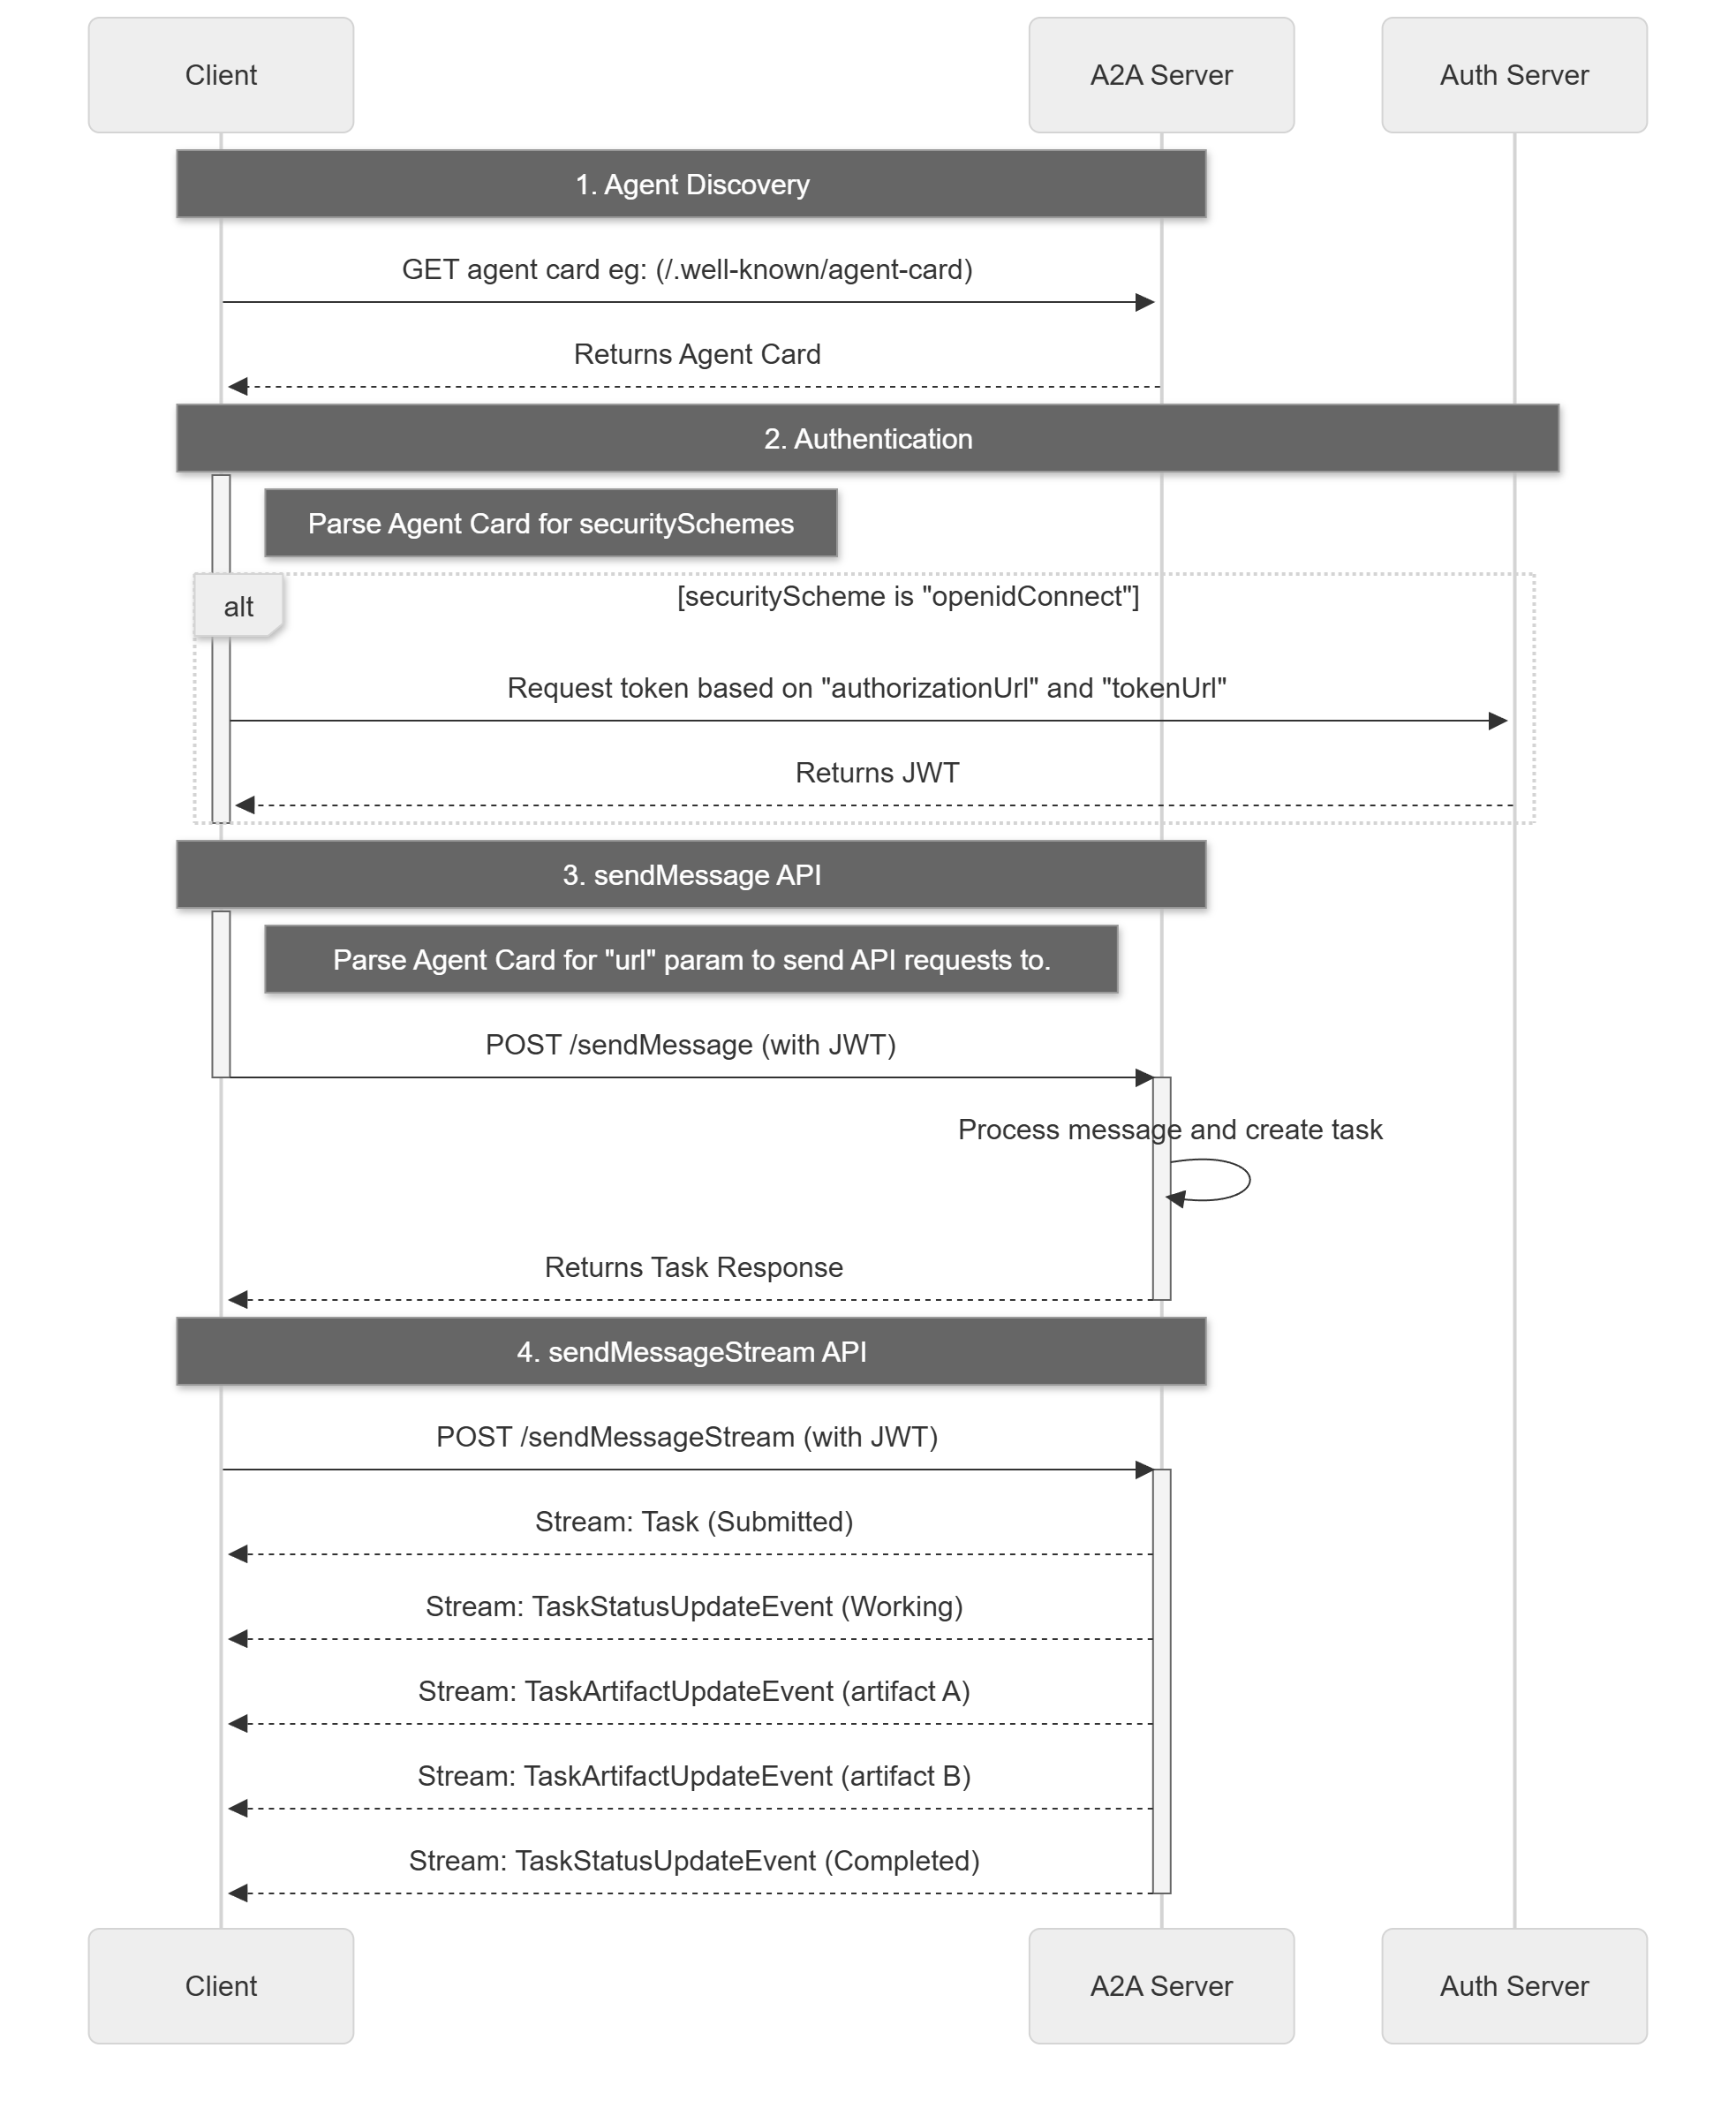

## 11.3 ANP
ANP 协议则专注于解决大规模、开放网络环境下的智能体管理问题。

| 概念           | 说明                                     | 示例                                                                 |
|----------------|------------------------------------------|----------------------------------------------------------------------|
| ANP Discovery  | 服务发现中心，用于注册和查询网络中的智能体服务。 | 一个中央服务器或一个P2P的DHT网络。                                     |
| Service Info   | 描述智能体服务的信息，包括其能力、地址和元数据。 | {"agent_id": "nlp-agent-01", …}                                       |
| ANP Network    | 对智能体网络的抽象，管理节点间的连接与通信。     | 整个智能体集群的拓扑视图。                                             |
| Capability     | 描述智能体功能的能力标签，用于服务发现时的匹配。 | "text_analysis", "image_processing"                                   |
| Metadata       | 服务的动态或静态元数据，用于路由决策。         | 负载情况、服务价格、软件版本等。                                       |

1. 服务的发现与匹配：首先，智能体 A 通过一个公开的发现服务，基于语义或功能描述进行查询，以定位到符合其任务需求的智能体 B。该发现服务通过预先爬取各智能体对外暴露的标准端点（.well-known/agent-descriptions）来建立索引，从而实现服务需求方与提供方的动态匹配。

2. 基于 DID 的身份验证：在交互开始时，智能体 A 使用其私钥对包含自身 DID 的请求进行签名。智能体 B 收到后，通过解析该 DID 获取对应的公钥，并以此验证签名的真实性与请求的完整性，从而建立起双方的可信通信。

3. 标准化的服务执行：身份验证通过后，智能体 B 响应请求，双方依据预定义的标准接口和数据格式进行数据交换或服务调用（如预订、查询等）。标准化的交互流程是实现跨平台、跨系统互操作性的基础。

该机制的核心是利用 DID 构建了一个去中心化的信任根基，并借助标准化的描述协议实现了服务的动态发现。这套方法使得智能体能够在无需中央协调的前提下，安全、高效地在互联网上形成协作网络。

# 12